In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision.transforms as transforms
from torch.utils.data import Dataset, DataLoader
from PIL import Image
import os
import numpy as np
import random
import matplotlib.pyplot as plt
import torchvision.models as models
from sklearn.cluster import KMeans

In [ ]:
class BreastCancerDataset(Dataset):
    def __init__(self, image_dir, transform=None):
        self.image_dir = image_dir
        self.image_files = [f for f in os.listdir(image_dir) if f.endswith((".png", ".jpg", ".jpeg"))]
        self.transform = transform

    def __len__(self):
        return len(self.image_files)

    def __getitem__(self, idx):
        img_name = self.image_files[idx]
        img_path = os.path.join(self.image_dir, img_name)

        # Load Image
        image = Image.open(img_path).convert("RGB")

        # Determine Malignancy (Based on Filename)
        label = 1 if "_class1" in img_name else 0  # 1 = Malignant, 0 = Benign

        if self.transform:
            image = self.transform(image)

        return image, label, img_name

In [ ]:
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5]),
])

In [ ]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)
data_dir = "/content/drive/MyDrive/cell-images"
dataset = BreastCancerDataset(image_dir=data_dir, transform=transform)
train_loader = DataLoader(dataset, batch_size=32, shuffle=True)

Mounted at /content/drive


In [ ]:
import os
os.listdir(data_dir)

['9226_idx5_x1451_y2201_class1.png',
 '9226_idx5_x1351_y2751_class1.png',
 '9226_idx5_x1501_y2151_class1.png',
 '9226_idx5_x1451_y2501_class1.png',
 '9226_idx5_x1451_y2751_class1.png',
 '9226_idx5_x1401_y2551_class1.png',
 '9226_idx5_x1401_y2101_class1.png',
 '9226_idx5_x1451_y2351_class1.png',
 '9226_idx5_x1351_y2451_class1.png',
 '9226_idx5_x1451_y2301_class1.png',
 '9226_idx5_x1401_y2451_class1.png',
 '9226_idx5_x1401_y2201_class1.png',
 '9226_idx5_x1401_y2401_class1.png',
 '9226_idx5_x1401_y2301_class1.png',
 '9226_idx5_x1401_y2151_class1.png',
 '9226_idx5_x1451_y2151_class1.png',
 '9226_idx5_x1501_y2101_class1.png',
 '9226_idx5_x1401_y2501_class1.png',
 '9226_idx5_x1351_y2551_class1.png',
 '9226_idx5_x1401_y2751_class1.png',
 '9226_idx5_x1401_y2351_class1.png',
 '9226_idx5_x1351_y2501_class1.png',
 '9226_idx5_x1451_y2401_class1.png',
 '9226_idx5_x1401_y2251_class1.png',
 '9226_idx5_x1451_y2251_class1.png',
 '9226_idx5_x1451_y2101_class1.png',
 '9226_idx5_x1451_y2551_class1.png',
 

In [ ]:
image_files = [f for f in os.listdir(data_dir) if f.endswith(('.png', '.jpg', '.jpeg', '.gif', '.bmp'))]
print(f"Total images: {len(image_files)}")
print(image_files[:10])  # Show first 10 images

Total images: 6330
['9226_idx5_x1451_y2201_class1.png', '9226_idx5_x1351_y2751_class1.png', '9226_idx5_x1501_y2151_class1.png', '9226_idx5_x1451_y2501_class1.png', '9226_idx5_x1451_y2751_class1.png', '9226_idx5_x1401_y2551_class1.png', '9226_idx5_x1401_y2101_class1.png', '9226_idx5_x1451_y2351_class1.png', '9226_idx5_x1351_y2451_class1.png', '9226_idx5_x1451_y2301_class1.png']


In [ ]:
import os
files = os.listdir(data_dir)
print(files)

['9226_idx5_x1451_y2201_class1.png', '9226_idx5_x1351_y2751_class1.png', '9226_idx5_x1501_y2151_class1.png', '9226_idx5_x1451_y2501_class1.png', '9226_idx5_x1451_y2751_class1.png', '9226_idx5_x1401_y2551_class1.png', '9226_idx5_x1401_y2101_class1.png', '9226_idx5_x1451_y2351_class1.png', '9226_idx5_x1351_y2451_class1.png', '9226_idx5_x1451_y2301_class1.png', '9226_idx5_x1401_y2451_class1.png', '9226_idx5_x1401_y2201_class1.png', '9226_idx5_x1401_y2401_class1.png', '9226_idx5_x1401_y2301_class1.png', '9226_idx5_x1401_y2151_class1.png', '9226_idx5_x1451_y2151_class1.png', '9226_idx5_x1501_y2101_class1.png', '9226_idx5_x1401_y2501_class1.png', '9226_idx5_x1351_y2551_class1.png', '9226_idx5_x1401_y2751_class1.png', '9226_idx5_x1401_y2351_class1.png', '9226_idx5_x1351_y2501_class1.png', '9226_idx5_x1451_y2401_class1.png', '9226_idx5_x1401_y2251_class1.png', '9226_idx5_x1451_y2251_class1.png', '9226_idx5_x1451_y2101_class1.png', '9226_idx5_x1451_y2551_class1.png', '9226_idx5_x1601_y2301_clas

In [ ]:
for file in files:
    file_path = os.path.join(data_dir, file)
    if os.path.isfile(file_path):
        print(f"File: {file} - Size: {os.path.getsize(file_path)} bytes")
    else:
        print(f"Folder: {file}")

Streaming output truncated to the last 5000 lines.
File: 9126_idx5_x2151_y1551_class1.png - Size: 6430 bytes
File: 9126_idx5_x2151_y901_class1.png - Size: 6547 bytes
File: 9126_idx5_x2151_y1651_class1.png - Size: 6685 bytes
File: 9126_idx5_x2201_y1351_class1.png - Size: 6162 bytes
File: 9126_idx5_x2151_y951_class1.png - Size: 6211 bytes
File: 9126_idx5_x2151_y1951_class1.png - Size: 6201 bytes
File: 9126_idx5_x2101_y901_class1.png - Size: 5715 bytes
File: 9126_idx5_x2151_y1201_class1.png - Size: 6224 bytes
File: 9126_idx5_x2201_y1251_class1.png - Size: 6233 bytes
File: 9126_idx5_x2201_y1101_class1.png - Size: 6340 bytes
File: 9126_idx5_x2151_y1101_class1.png - Size: 6443 bytes
File: 9126_idx5_x2201_y1001_class1.png - Size: 6426 bytes
File: 9126_idx5_x2251_y1201_class1.png - Size: 6145 bytes
File: 9126_idx5_x2201_y1751_class1.png - Size: 6415 bytes
File: 9126_idx5_x2251_y1701_class1.png - Size: 6518 bytes
File: 9126_idx5_x2251_y1801_class1.png - Size: 6308 bytes
File: 9126_idx5_x2201_y1

In [ ]:
from PIL import Image

for img in files[:5]:  # Checking first 5 images
    img_path = os.path.join(data_dir, img)
    with Image.open(img_path) as image:
        print(f"Image: {img} | Format: {image.format} | Size: {image.size} | Mode: {image.mode}")


Image: 9226_idx5_x1451_y2201_class1.png | Format: PNG | Size: (50, 50) | Mode: RGB
Image: 9226_idx5_x1351_y2751_class1.png | Format: PNG | Size: (50, 50) | Mode: RGB
Image: 9226_idx5_x1501_y2151_class1.png | Format: PNG | Size: (50, 50) | Mode: RGB
Image: 9226_idx5_x1451_y2501_class1.png | Format: PNG | Size: (50, 50) | Mode: RGB
Image: 9226_idx5_x1451_y2751_class1.png | Format: PNG | Size: (50, 50) | Mode: RGB


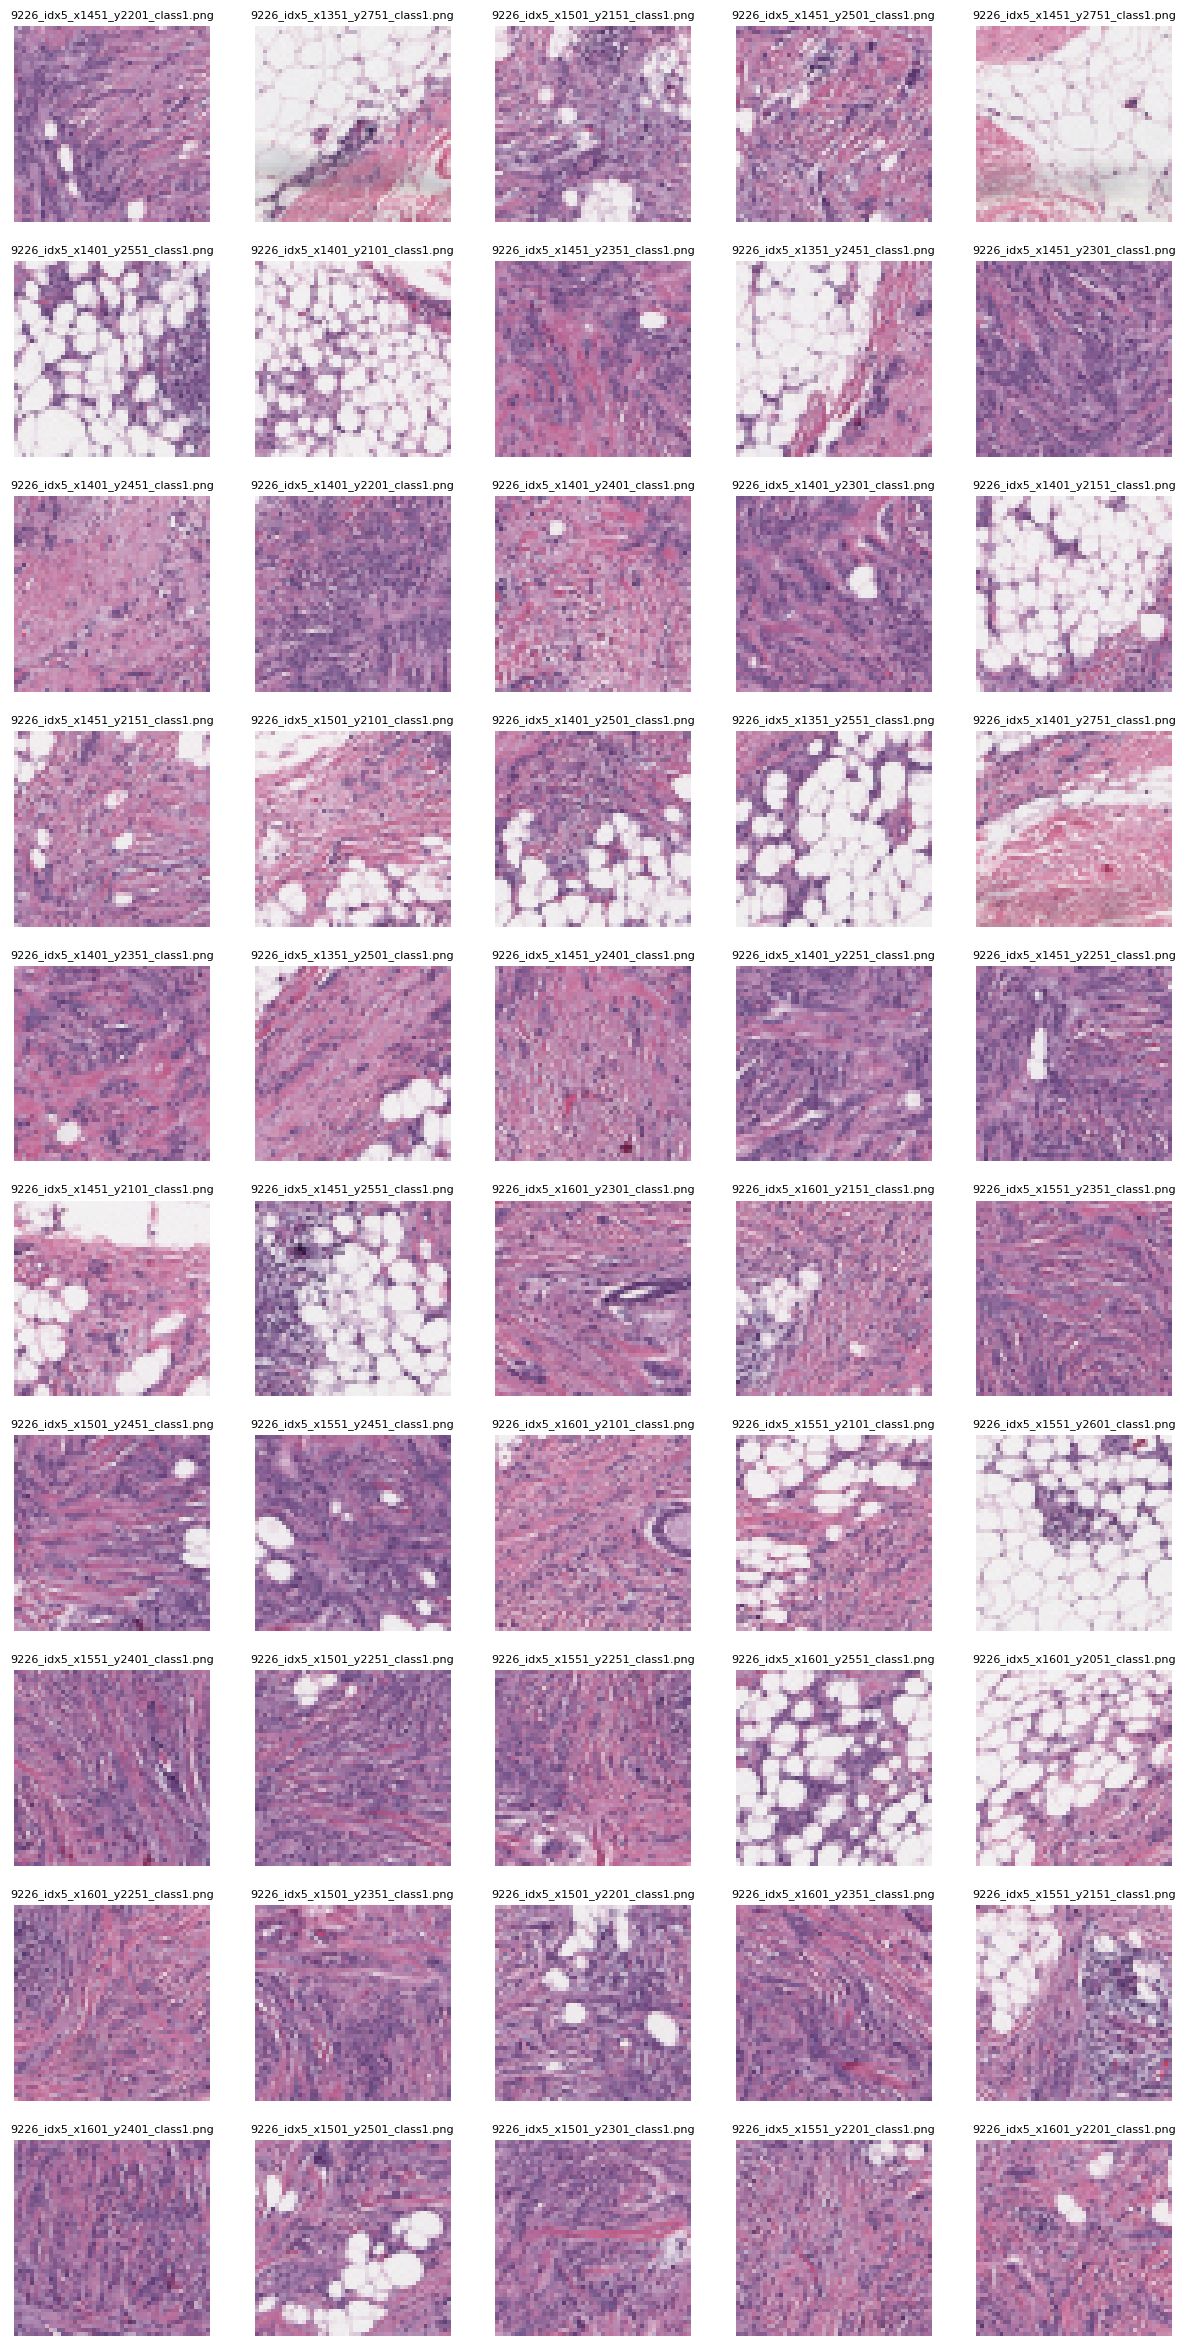

In [ ]:
fig, axes = plt.subplots(10, 5, figsize=(15, 30))  # 10 rows, 5 columns
for i, img in enumerate(files[:50]):
    img_path = os.path.join(data_dir, img)
    image = Image.open(img_path)
    ax = axes[i // 5, i % 5]
    ax.imshow(image)
    ax.axis("off")
    ax.set_title(img, fontsize=8)

plt.show()


In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

class CancerClassifier(nn.Module):
    def __init__(self):
        super(CancerClassifier, self).__init__()
        self.model = models.resnet18(pretrained=True)
        num_ftrs = self.model.fc.in_features
        self.model.fc = nn.Linear(num_ftrs, 2)  # 2 classes (Benign, Malignant)

    def forward(self, x):
        return self.model(x)

# Initialize Model
model = CancerClassifier().to(device)

In [ ]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

num_epochs = 15
train_losses = []
train_accuracies = []

for epoch in range(num_epochs):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels, _ in train_loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        _, predicted = outputs.max(1)
        correct += (predicted == labels).sum().item()
        total += labels.size(0)

    epoch_loss = running_loss / len(train_loader)
    epoch_acc = correct / total * 100
    train_losses.append(epoch_loss)
    train_accuracies.append(epoch_acc)

    print(f"Epoch {epoch+1}/{num_epochs} - Loss: {epoch_loss:.4f}, Accuracy: {epoch_acc:.2f}%")

Epoch 1/15 - Loss: 0.3084, Accuracy: 88.26%
Epoch 2/15 - Loss: 0.2119, Accuracy: 92.05%
Epoch 3/15 - Loss: 0.1906, Accuracy: 92.89%
Epoch 4/15 - Loss: 0.1623, Accuracy: 93.95%
Epoch 5/15 - Loss: 0.1546, Accuracy: 94.08%
Epoch 6/15 - Loss: 0.1392, Accuracy: 94.58%
Epoch 7/15 - Loss: 0.1204, Accuracy: 95.42%
Epoch 8/15 - Loss: 0.1062, Accuracy: 95.94%
Epoch 9/15 - Loss: 0.1068, Accuracy: 96.22%
Epoch 10/15 - Loss: 0.0786, Accuracy: 97.06%
Epoch 11/15 - Loss: 0.0698, Accuracy: 97.41%
Epoch 12/15 - Loss: 0.0813, Accuracy: 97.00%
Epoch 13/15 - Loss: 0.0494, Accuracy: 98.26%
Epoch 14/15 - Loss: 0.0454, Accuracy: 98.20%
Epoch 15/15 - Loss: 0.0446, Accuracy: 98.39%


In [ ]:
model_path = "/content/drive/MyDrive/resnet18_cancer_classifier2.pth"
torch.save(model.state_dict(), model_path)
print(f"✅ Model saved at: {model_path}")

✅ Model saved at: /content/drive/MyDrive/resnet18_cancer_classifier2.pth


In [ ]:
model.eval()
feature_extractor = torch.nn.Sequential(*list(model.model.children())[:-1])  # Remove last FC layer

malignant_features = []
malignant_filenames = []

# Extract features for malignant cases
for images, labels, filenames in train_loader:
    images = images.to(device)
    with torch.no_grad():
        features = feature_extractor(images).squeeze()  # Get ResNet features

    for i, label in enumerate(labels):
        if label.item() == 1:  # Only for malignant cases
            malignant_features.append(features[i].cpu().numpy())
            malignant_filenames.append(filenames[i])

# Convert to NumPy for clustering
malignant_features = np.array(malignant_features)

# Apply K-Means Clustering (4 Clusters = 4 Stages)
kmeans = KMeans(n_clusters=4, random_state=42)
stages = kmeans.fit_predict(malignant_features)

# Map filenames to predicted stages
stage_predictions = {filename: stage + 1 for filename, stage in zip(malignant_filenames, stages)}

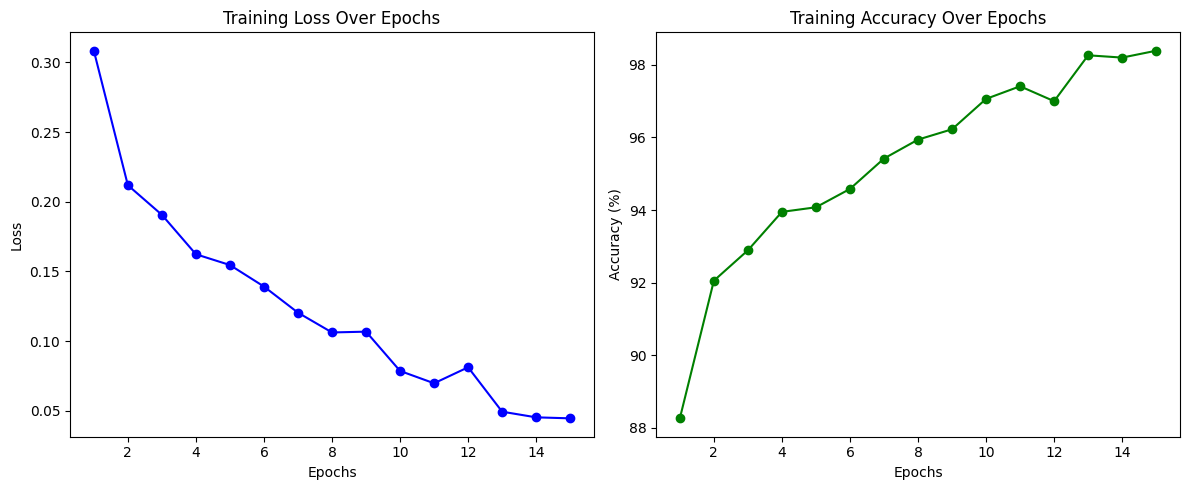

In [ ]:
plt.figure(figsize=(12, 5))

# Loss Plot
plt.subplot(1, 2, 1)
plt.plot(range(1, num_epochs + 1), train_losses, marker='o', linestyle='-', color='b')
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Training Loss Over Epochs")

# Accuracy Plot
plt.subplot(1, 2, 2)
plt.plot(range(1, num_epochs + 1), train_accuracies, marker='o', linestyle='-', color='g')
plt.xlabel("Epochs")
plt.ylabel("Accuracy (%)")
plt.title("Training Accuracy Over Epochs")

plt.tight_layout()
plt.show()

In [ ]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)


Mounted at /content/drive


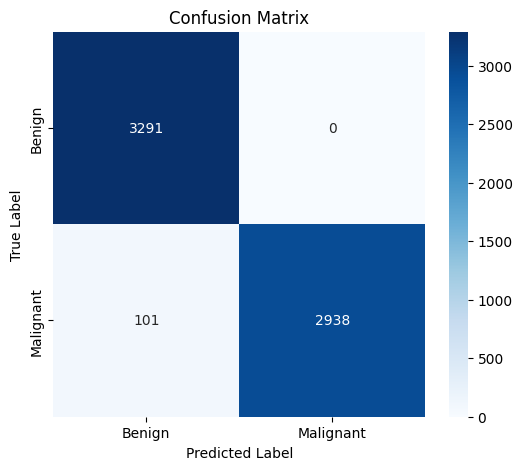

              precision    recall  f1-score   support

      Benign       0.97      1.00      0.98      3291
   Malignant       1.00      0.97      0.98      3039

    accuracy                           0.98      6330
   macro avg       0.99      0.98      0.98      6330
weighted avg       0.98      0.98      0.98      6330

Accuracy: 98.39%


In [ ]:
from sklearn.metrics import roc_curve, auc, confusion_matrix, classification_report
import seaborn as sns
import torch.nn.functional as F

# Prepare model for evaluation
model.eval()
y_true = []
y_scores = []
y_preds = []

# Iterate through the dataset and collect predictions
with torch.no_grad():
    for images, labels, _ in train_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        probabilities = F.softmax(outputs, dim=1)[:, 1]  # Probabilities for class 1 (malignant)
        predictions = outputs.argmax(dim=1)  # Predicted class

        y_true.extend(labels.cpu().numpy())
        y_scores.extend(probabilities.cpu().numpy())
        y_preds.extend(predictions.cpu().numpy())

# Compute confusion matrix
conf_matrix = confusion_matrix(y_true, y_preds)

# Plot confusion matrix
plt.figure(figsize=(6, 5))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=['Benign', 'Malignant'], yticklabels=['Benign', 'Malignant'])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.show()

# Print classification report
print(classification_report(y_true, y_preds, target_names=['Benign', 'Malignant']))
print(f"Accuracy: {epoch_acc:.2f}%")

In [ ]:
import torch
import torchvision.transforms as transforms
from PIL import Image
import os
import random
import matplotlib.pyplot as plt
import torchvision.models as models

# Define paths
data_dir = "/content/drive/MyDrive/cell-images"  # Update with your dataset path
model_path = "/content/drive/MyDrive/resnet18_cancer_classifier2.pth"  # Trained model path

# Define device
def classify_image(image_path):
    image = Image.open(image_path).convert("RGB")
    image_tensor = transform(image).unsqueeze(0).to(device)

    with torch.no_grad():
        output = model(image_tensor)
        _, predicted = torch.max(output, 1)

    classes = ["Benign", "Malignant"]
    result = classes[predicted.item()]

    if result == "Malignant":
        stage = stage_predictions.get(image_path.split("/")[-1], "Unknown")
        print(f"Prediction: {result} (Stage {stage})")
    else:
        print(f"Prediction: {result} (No Stage)")

    plt.imshow(image)
    plt.title(f"Prediction: {result} (Stage {stage if result == 'Malignant' else 'N/A'})")
    plt.axis("off")
    plt.show()


In [ ]:
import torch
from torchvision import models, transforms
from PIL import Image
import torch.nn as nn

# Define device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Define the model architecture again
class CancerClassifier(nn.Module):
    def __init__(self):
        super(CancerClassifier, self).__init__()
        self.model = models.resnet18(pretrained=True)
        num_ftrs = self.model.fc.in_features
        self.model.fc = nn.Linear(num_ftrs, 2)  # 2 classes: Benign, Malignant

    def forward(self, x):
        return self.model(x)

# Load the trained model
model = CancerClassifier().to(device)
model.load_state_dict(torch.load("/content/drive/MyDrive/resnet18_cancer_classifier2.pth", map_location=device))
model.eval()

# Define the image transform (same as used during training)
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],  # ImageNet mean
                         [0.229, 0.224, 0.225])  # ImageNet std
])

# Prediction function
def predict_image(image_path):
    image = Image.open(image_path).convert('RGB')
    input_tensor = transform(image).unsqueeze(0).to(device)  # Add batch dimension
    with torch.no_grad():
        output = model(input_tensor)
        _, predicted = torch.max(output, 1)
        class_names = ['Benign', 'Malignant']
        prediction = class_names[predicted.item()]
    return prediction

# Example usage:
image_path = "/content/drive/MyDrive/8951_idx5_x1301_y951_class1.png"  # Change to your image path
result = predict_image(image_path)
print(f"🧪 Prediction: {result}")
